# TAME Benchmark - QM8 Multi-Task Regression

Minimal TAME benchmark for QM8 with PT-S1 encoder initialization (Chemeleon stage-1 checkpoint).

In [1]:
# === Setup ===
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors

RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.error')

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / 'models').exists()), here)
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Workspace: {workspace_root}')
print(f'Device: {device}')

Workspace: C:\Users\robsc\Home\Dev\molfusion2
Device: cuda


In [2]:
# === Configuration ===
CONFIG = {
    # Reproducibility
    'seed': 42,

    # Encoder architecture
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'set2set',
    'set2set_processing_steps': 6,

    # TAME/TAME fusion
    'fusion_hidden_dim': 64,
    'projection_dropout': 0.30,
    'router_dropout': 0.35,
    'head_hidden_dim': 64,
    'head_dropout': 0.30,
    'gate_balance_weight': 0.005,
    'desc_modality_dropout': 0.25,

    # Descriptor preprocessing
    'descriptor_winsorize_lower_q': 0.01,
    'descriptor_winsorize_upper_q': 0.99,
    'descriptor_standardize': True,

    # Training
    'learning_rate': 7e-4,
    'weight_decay': 7e-2,
    'batch_size': 64,
    'num_epochs': 100,
    'patience': 15,

    # Data/task
    'num_tasks': 16,
    'split_type': 'random',

    # Embeddings
    'embedding_task': 'quantum_fast',

    # Pretraining
    'use_pt_s1': True,
    'pretrain_stage': 'stage1_node',
}

if CONFIG['seed'] is not None:
    set_seed(int(CONFIG['seed']))

print('=== TAME QM8 Configuration ===')
print(f"Seed: {CONFIG['seed']}")
print(f"Encoder: h={CONFIG['hidden_channels']}, L={CONFIG['num_layers']}, K={CONFIG['K']}, pool={CONFIG['pool']}")
print(f"Fusion hidden: {CONFIG['fusion_hidden_dim']} | Gate balance: {CONFIG['gate_balance_weight']}")
print(f"Dropout: projection={CONFIG['projection_dropout']}, router={CONFIG['router_dropout']}, head={CONFIG['head_dropout']}")
print(f"Use PT-S1: {CONFIG['use_pt_s1']}")

=== TAME QM8 Configuration ===
Seed: 42
Encoder: h=128, L=3, K=3, pool=set2set
Fusion hidden: 64 | Gate balance: 0.005
Dropout: projection=0.3, router=0.35, head=0.3
Use PT-S1: True


In [3]:
# === Load QM8 Dataset ===
import deepchem as dc

tasks, datasets, transformers = dc.molnet.load_qm8(
    featurizer='ECFP',
    splitter='scaffold' if CONFIG['split_type'] == 'scaffold' else 'random',
)
train_dc, valid_dc, test_dc = datasets
QM8_TASKS = list(tasks)

train_smiles = list(train_dc.ids)
valid_smiles = list(valid_dc.ids)
test_smiles = list(test_dc.ids)

train_y = np.asarray(train_dc.y, dtype=np.float32)
valid_y = np.asarray(valid_dc.y, dtype=np.float32)
test_y = np.asarray(test_dc.y, dtype=np.float32)

train_y_orig = train_y.copy()
valid_y_orig = valid_y.copy()
test_y_orig = test_y.copy()
for transformer in reversed(transformers):
    train_y_orig = transformer.untransform(train_y_orig)
    valid_y_orig = transformer.untransform(valid_y_orig)
    test_y_orig = transformer.untransform(test_y_orig)
train_y_orig = train_y_orig.astype(np.float32)
valid_y_orig = valid_y_orig.astype(np.float32)
test_y_orig = test_y_orig.astype(np.float32)

print(f"Split: {CONFIG['split_type']} | Train: {len(train_smiles)} | Valid: {len(valid_smiles)} | Test: {len(test_smiles)}")
print(f'Tasks: {len(QM8_TASKS)}')
print(f"Transformers: {[type(t).__name__ for t in transformers]}")

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-geometric depe

Split: random | Train: 17397 | Valid: 2175 | Test: 2175
Tasks: 16
Transformers: ['NormalizationTransformer']


In [4]:
# === Load Text Embeddings ===
from utils.embedding_cache import EfficientEmbeddingCache

emb_dir = workspace_root / 'cache' / 'cot_embeddings'
npz_path = emb_dir / f"{CONFIG['embedding_task']}_text_embeddings_compact.npz"
if not npz_path.exists():
    raise FileNotFoundError(f'Embedding cache not found: {npz_path}')

cache = EfficientEmbeddingCache.load(npz_path)
all_smiles = train_smiles + valid_smiles + test_smiles
all_emb = cache.get_batch(all_smiles).astype(np.float32)

n_train = len(train_smiles)
n_valid = len(valid_smiles)
train_text_emb = all_emb[:n_train]
valid_text_emb = all_emb[n_train:n_train + n_valid]
test_text_emb = all_emb[n_train + n_valid:]

print(f"Loaded embeddings: {npz_path.name} ({len(cache)} molecules)")
print(f"Shapes: train={train_text_emb.shape}, valid={valid_text_emb.shape}, test={test_text_emb.shape}")

Loading embeddings from quantum_fast_text_embeddings_compact.npz...
  Loaded 21722 entries, dim=3072
  Memory mode: mapped
Loaded embeddings: quantum_fast_text_embeddings_compact.npz (21722 molecules)
Shapes: train=(17397, 3072), valid=(2175, 3072), test=(2175, 3072)


In [5]:
# === Build RDKit Descriptors ===
def rdkit_descriptor_matrix(smiles_list):
    desc_names = [name for name, _ in Descriptors.descList]
    rows = []
    n_desc = len(desc_names)
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append(np.full((n_desc,), np.nan, dtype=np.float32))
            continue

        all_desc = Descriptors.CalcMolDescriptors(mol)
        row = []
        for name in desc_names:
            try:
                row.append(float(all_desc.get(name, np.nan)))
            except Exception:
                row.append(np.nan)
        rows.append(np.asarray(row, dtype=np.float32))

    return np.vstack(rows).astype(np.float32), desc_names

def impute_with_train_median(train_X, valid_X, test_X):
    med = np.nanmedian(train_X, axis=0)
    med = np.where(np.isfinite(med), med, 0.0).astype(np.float32)

    def _imp(X):
        X = np.asarray(X, dtype=np.float32)
        mask = ~np.isfinite(X)
        if mask.any():
            X = X.copy()
            X[mask] = np.take(med, np.where(mask)[1])
        return X

    return _imp(train_X), _imp(valid_X), _imp(test_X)

d_train, desc_names = rdkit_descriptor_matrix(train_smiles)
d_valid, _ = rdkit_descriptor_matrix(valid_smiles)
d_test, _ = rdkit_descriptor_matrix(test_smiles)
d_train, d_valid, d_test = impute_with_train_median(d_train, d_valid, d_test)

print(f'Descriptor dim: {d_train.shape[1]}')
print(f'Missing values after imputation (train): {int((~np.isfinite(d_train)).sum())}')

Descriptor dim: 217
Missing values after imputation (train): 0


In [6]:
# === TAME Model + PT-S1 Checkpoint Loading ===
from models.tame_predictor import TAMEPredictor, TAMEPredictorConfig

def _arch_from_encoder_state(encoder_state):
    layer_ids = sorted({
        int(k.split('.')[1])
        for k in encoder_state.keys()
        if k.startswith('layers.') and k.endswith('.weight')
    })
    if not layer_ids:
        raise RuntimeError('No encoder layer weights found in encoder_state.')

    first_weight_key = f'layers.{layer_ids[0]}.weight'
    first_weight = encoder_state[first_weight_key]
    if first_weight.ndim != 3:
        raise RuntimeError(
            f'Unexpected encoder weight shape for {first_weight_key}: {tuple(first_weight.shape)}'
        )

    return {
        'K': int(first_weight.shape[0]),
        'hidden_channels': int(first_weight.shape[-1]),
        'num_layers': int(max(layer_ids) + 1),
    }

def resolve_pretrain_checkpoint(pretrain_stage, *, hidden_channels, num_layers, K, pool):
    stage_cfg = {
        'stage1_node': {'pattern_prefix': 'cheb_foundation_stage1'},
        'stage2_descriptor': {'pattern_prefix': 'cheb_foundation_2stage'},
    }
    if pretrain_stage not in stage_cfg:
        raise ValueError(f'Unsupported pretrain_stage={pretrain_stage!r}')

    ckpt_dir = workspace_root / 'cache' / 'chemeleon_pretraining'
    if not ckpt_dir.exists():
        raise FileNotFoundError(f'Checkpoint directory not found: {ckpt_dir}')

    pattern_prefix = stage_cfg[pretrain_stage]['pattern_prefix']
    pattern = f"{pattern_prefix}__h{int(hidden_channels)}__L{int(num_layers)}__K{int(K)}__pool-{pool}__*.pt"
    candidates = sorted(
        [p for p in ckpt_dir.glob(pattern) if '__fallback__' not in p.name],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        raise FileNotFoundError(
            f"No checkpoint found for stage={pretrain_stage!r} with required pattern={pattern!r}."
        )
    return candidates[0]

def load_pretrained_encoder_state(ckpt_path, expected_stage, expected_arch):
    payload = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    if not isinstance(payload, dict):
        raise RuntimeError('Invalid checkpoint payload format.')

    stage = payload.get('pretraining_stage', None)
    if stage != expected_stage:
        raise RuntimeError(
            f"Expected checkpoint with pretraining_stage={expected_stage!r}, got {stage!r}"
        )

    model_state = payload.get('model_state_dict', {})
    enc_state = {k.replace('encoder.', '', 1): v for k, v in model_state.items() if k.startswith('encoder.')}
    if not enc_state:
        raise RuntimeError('Checkpoint does not contain encoder.* weights.')

    arch = _arch_from_encoder_state(enc_state)
    for k in ('hidden_channels', 'K', 'num_layers'):
        if int(arch[k]) != int(expected_arch[k]):
            raise RuntimeError(
                f"Checkpoint architecture mismatch for {Path(ckpt_path).name}: {k}={arch[k]} but expected {expected_arch[k]}"
            )

    print(f'Loaded {expected_stage} encoder state from: {Path(ckpt_path).resolve()}')
    return enc_state

tame_config = TAMEPredictorConfig(
    task='regression',
    num_tasks=CONFIG['num_tasks'],
    hidden_channels=CONFIG['hidden_channels'],
    K=CONFIG['K'],
    num_layers=CONFIG['num_layers'],
    pool=CONFIG['pool'],
    set2set_processing_steps=CONFIG['set2set_processing_steps'],
    text_embedding_dim=int(train_text_emb.shape[1]),
    fusion_hidden_dim=CONFIG['fusion_hidden_dim'],
    projection_dropout=CONFIG['projection_dropout'],
    router_dropout=CONFIG['router_dropout'],
    head_hidden_dim=CONFIG['head_hidden_dim'],
    head_dropout=CONFIG['head_dropout'],
    gate_balance_weight=CONFIG['gate_balance_weight'],
    desc_modality_dropout=CONFIG['desc_modality_dropout'],
    descriptor_winsorize_lower_q=CONFIG['descriptor_winsorize_lower_q'],
    descriptor_winsorize_upper_q=CONFIG['descriptor_winsorize_upper_q'],
    descriptor_standardize=CONFIG['descriptor_standardize'],
    add_hydrogens=False,
)

encoder_init_state = None
if CONFIG['use_pt_s1']:
    expected_arch = {
        'hidden_channels': int(CONFIG['hidden_channels']),
        'num_layers': int(CONFIG['num_layers']),
        'K': int(CONFIG['K']),
        'pool': CONFIG['pool'],
    }
    ckpt_path = resolve_pretrain_checkpoint(CONFIG['pretrain_stage'], **expected_arch)
    encoder_init_state = load_pretrained_encoder_state(
        ckpt_path,
        expected_stage=CONFIG['pretrain_stage'],
        expected_arch=expected_arch,
    )

tame = TAMEPredictor(config=tame_config, device=str(device))
print(f"Initialized TAME (TAME): tasks={CONFIG['num_tasks']}, text_dim={train_text_emb.shape[1]}")

Loaded stage1_node encoder state from: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt
Initialized TAME (TAME): tasks=16, text_dim=3072


In [7]:
# === Train TAME ===
history = tame.fit(
    smiles_list=train_smiles,
    labels=train_y.tolist(),
    val_smiles=valid_smiles,
    val_labels=valid_y.tolist(),
    text_embeddings=train_text_emb,
    val_text_embeddings=valid_text_emb,
    descriptor_features=d_train,
    val_descriptor_features=d_valid,
    num_epochs=CONFIG['num_epochs'],
    batch_size=CONFIG['batch_size'],
    learning_rate=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay'],
    patience=CONFIG['patience'],
    seed=int(CONFIG['seed'] or 0),
    verbose=True,
    init_encoder_state=encoder_init_state,
)

n_params_tame = 0
if tame._encoder is not None:
    n_params_tame += sum(p.numel() for p in tame._encoder.parameters())
if tame._pooling is not None:
    n_params_tame += sum(p.numel() for p in tame._pooling.parameters())
if tame._moe_module is not None:
    n_params_tame += sum(p.numel() for p in tame._moe_module.parameters())

print(f'TAME parameters: {n_params_tame:,}')

Descriptor preprocessing enabled (winsor q=[0.010, 0.990], standardize=True)
Initialized TAME encoder from external checkpoint state
Epoch 001 | train=0.932968 | val=0.901059 | gates G/T/D=0.339/0.315/0.346
Epoch 005 | train=0.864184 | val=0.855017 | gates G/T/D=0.345/0.341/0.313
Epoch 010 | train=0.820052 | val=0.824700 | gates G/T/D=0.350/0.360/0.290
Epoch 015 | train=0.781728 | val=0.810694 | gates G/T/D=0.374/0.347/0.279
Epoch 020 | train=0.746750 | val=0.788546 | gates G/T/D=0.383/0.345/0.272
Epoch 025 | train=0.710432 | val=0.789852 | gates G/T/D=0.390/0.340/0.270
Epoch 030 | train=0.678318 | val=0.783677 | gates G/T/D=0.387/0.339/0.273
Epoch 035 | train=0.655750 | val=0.770634 | gates G/T/D=0.395/0.342/0.263
Epoch 040 | train=0.633041 | val=0.785775 | gates G/T/D=0.396/0.348/0.256
Epoch 045 | train=0.617612 | val=0.772090 | gates G/T/D=0.395/0.343/0.263
Epoch 050 | train=0.600330 | val=0.757872 | gates G/T/D=0.401/0.344/0.256
Epoch 055 | train=0.582607 | val=0.771065 | gates G/T

In [8]:
# === Evaluation: Per-Task MAE (Original Scale) ===
def inverse_transform(arr, transformers):
    x = np.asarray(arr, dtype=np.float32).copy()
    for tr in reversed(transformers):
        x = tr.untransform(x)
    return np.asarray(x, dtype=np.float32)

def compute_mae(y_true, y_pred):
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return np.mean(np.abs(y_true[mask] - y_pred[mask])) if int(mask.sum()) > 0 else np.nan

valid_preds_norm = tame.predict_batch(
    valid_smiles,
    text_embeddings=valid_text_emb,
    descriptor_features=d_valid,
)
test_preds_norm = tame.predict_batch(
    test_smiles,
    text_embeddings=test_text_emb,
    descriptor_features=d_test,
)

valid_preds = inverse_transform(valid_preds_norm, transformers)
test_preds = inverse_transform(test_preds_norm, transformers)

print('=== Per-Task MAE (x1e-3) - Original Scale ===')
print(f"{'Task':40} {'Valid MAE':>15} {'Test MAE':>15}")
print('-' * 72)

valid_maes = []
test_maes = []
for i, task in enumerate(QM8_TASKS):
    v_mae = compute_mae(valid_y_orig[:, i], valid_preds[:, i])
    t_mae = compute_mae(test_y_orig[:, i], test_preds[:, i])
    valid_maes.append(v_mae)
    test_maes.append(t_mae)
    print(f"{task:40} {v_mae * 1000:>15.4f} {t_mae * 1000:>15.4f}")

mean_valid_mae = float(np.nanmean(valid_maes))
mean_test_mae = float(np.nanmean(test_maes))
std_valid_mae = float(np.nanstd(valid_maes))
std_test_mae = float(np.nanstd(test_maes))

print('-' * 72)
print(f"{'Mean':40} {mean_valid_mae * 1000:>15.4f} {mean_test_mae * 1000:>15.4f}")
print(f"{'Std':40} {std_valid_mae * 1000:>15.4f} {std_test_mae * 1000:>15.4f}")
print()
print(f"Macro MAE (test): {mean_test_mae:.6f}")
print(f"Config: pool={CONFIG['pool']}, fusion_hidden={CONFIG['fusion_hidden_dim']}, PT-S1={CONFIG['use_pt_s1']}")

=== Per-Task MAE (x1e-3) - Original Scale ===
Task                                           Valid MAE        Test MAE
------------------------------------------------------------------------
E1-CC2                                           29.0567         29.8420
E2-CC2                                           22.1112         22.4100
f1-CC2                                           31.3728         30.5427
f2-CC2                                           47.8333         49.3604
E1-PBE0                                          31.1274         31.9189
E2-PBE0                                          25.3132         25.6550
f1-PBE0                                          30.3589         29.0291
f2-PBE0                                          37.8869         37.3948
E1-PBE0                                          31.1274         31.9189
E2-PBE0                                          25.3132         25.6550
f1-PBE0                                          30.3589         29.0291
f2-PB

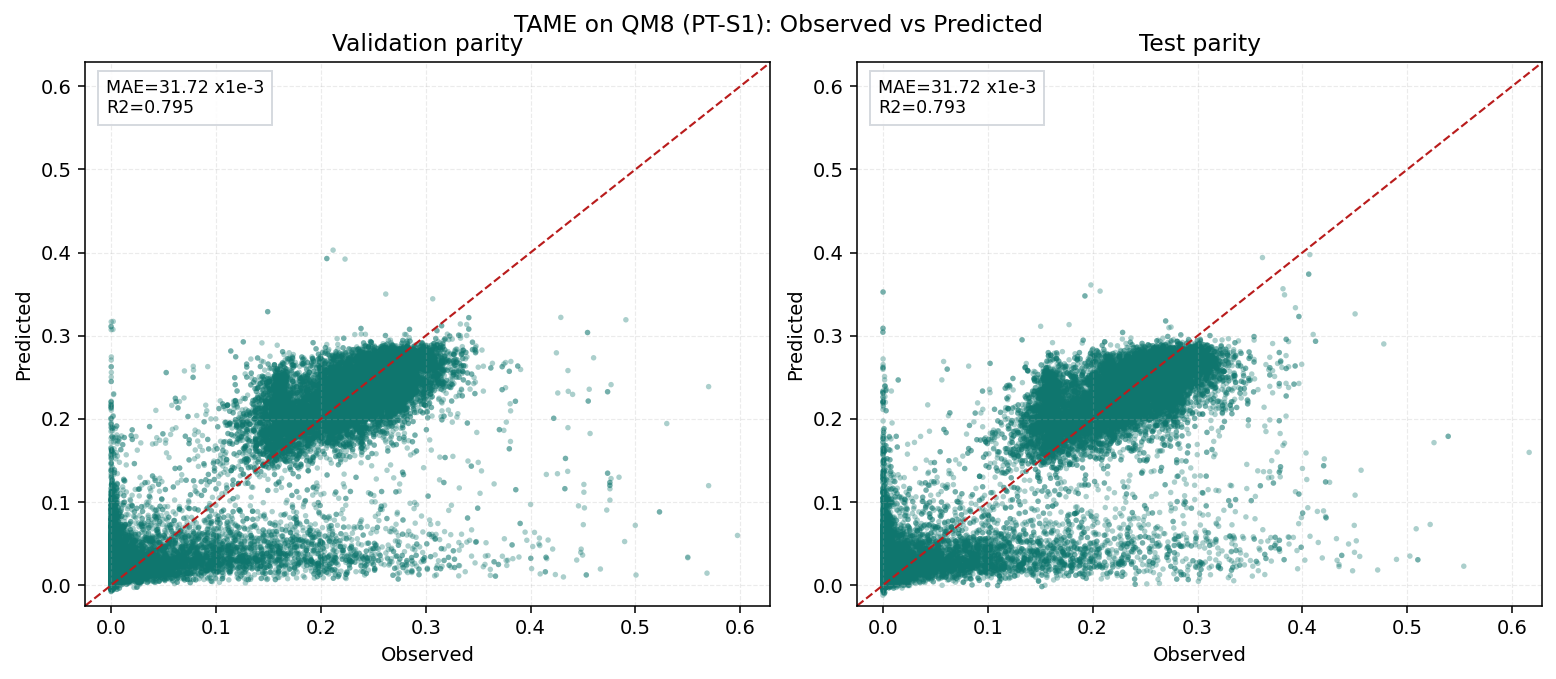

In [9]:
# === Parity Plots (Valid/Test) ===
def flatten_finite(y_true_2d, y_pred_2d):
    yt = np.asarray(y_true_2d, dtype=np.float32).reshape(-1)
    yp = np.asarray(y_pred_2d, dtype=np.float32).reshape(-1)
    mask = np.isfinite(yt) & np.isfinite(yp)
    return yt[mask], yp[mask]

def r2_score_np(y_true_1d, y_pred_1d):
    y_true_1d = np.asarray(y_true_1d, dtype=np.float32)
    y_pred_1d = np.asarray(y_pred_1d, dtype=np.float32)
    ss_res = float(np.sum((y_true_1d - y_pred_1d) ** 2))
    ss_tot = float(np.sum((y_true_1d - np.mean(y_true_1d)) ** 2))
    return np.nan if ss_tot <= 0 else 1.0 - (ss_res / ss_tot)

yt_valid, yp_valid = flatten_finite(valid_y_orig, valid_preds)
yt_test, yp_test = flatten_finite(test_y_orig, test_preds)

mae_valid = float(np.mean(np.abs(yp_valid - yt_valid)))
mae_test = float(np.mean(np.abs(yp_test - yt_test)))
r2_valid = r2_score_np(yt_valid, yp_valid)
r2_test = r2_score_np(yt_test, yp_test)

lo = float(np.min(np.concatenate([yt_valid, yp_valid, yt_test, yp_test])))
hi = float(np.max(np.concatenate([yt_valid, yp_valid, yt_test, yp_test])))
pad = 0.02 * (hi - lo + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), dpi=140, constrained_layout=True)
for ax, yt, yp, split, mae, r2 in [
    (axes[0], yt_valid, yp_valid, 'Validation', mae_valid, r2_valid),
    (axes[1], yt_test, yp_test, 'Test', mae_test, r2_test),
]:
    ax.scatter(yt, yp, s=8, alpha=0.35, c='#0f766e', edgecolors='none')
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], '--', lw=1.1, c='#b91c1c')
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel('Observed')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{split} parity')
    ax.grid(alpha=0.25, linestyle='--', linewidth=0.6)
    ax.text(
        0.03,
        0.97,
        f'MAE={mae * 1000:.2f} x1e-3\nR2={r2:.3f}',
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(facecolor='white', edgecolor='#d1d5db', alpha=0.9),
    )

fig.suptitle('TAME on QM8 (PT-S1): Observed vs Predicted', fontsize=12, y=1.02)
plt.show()

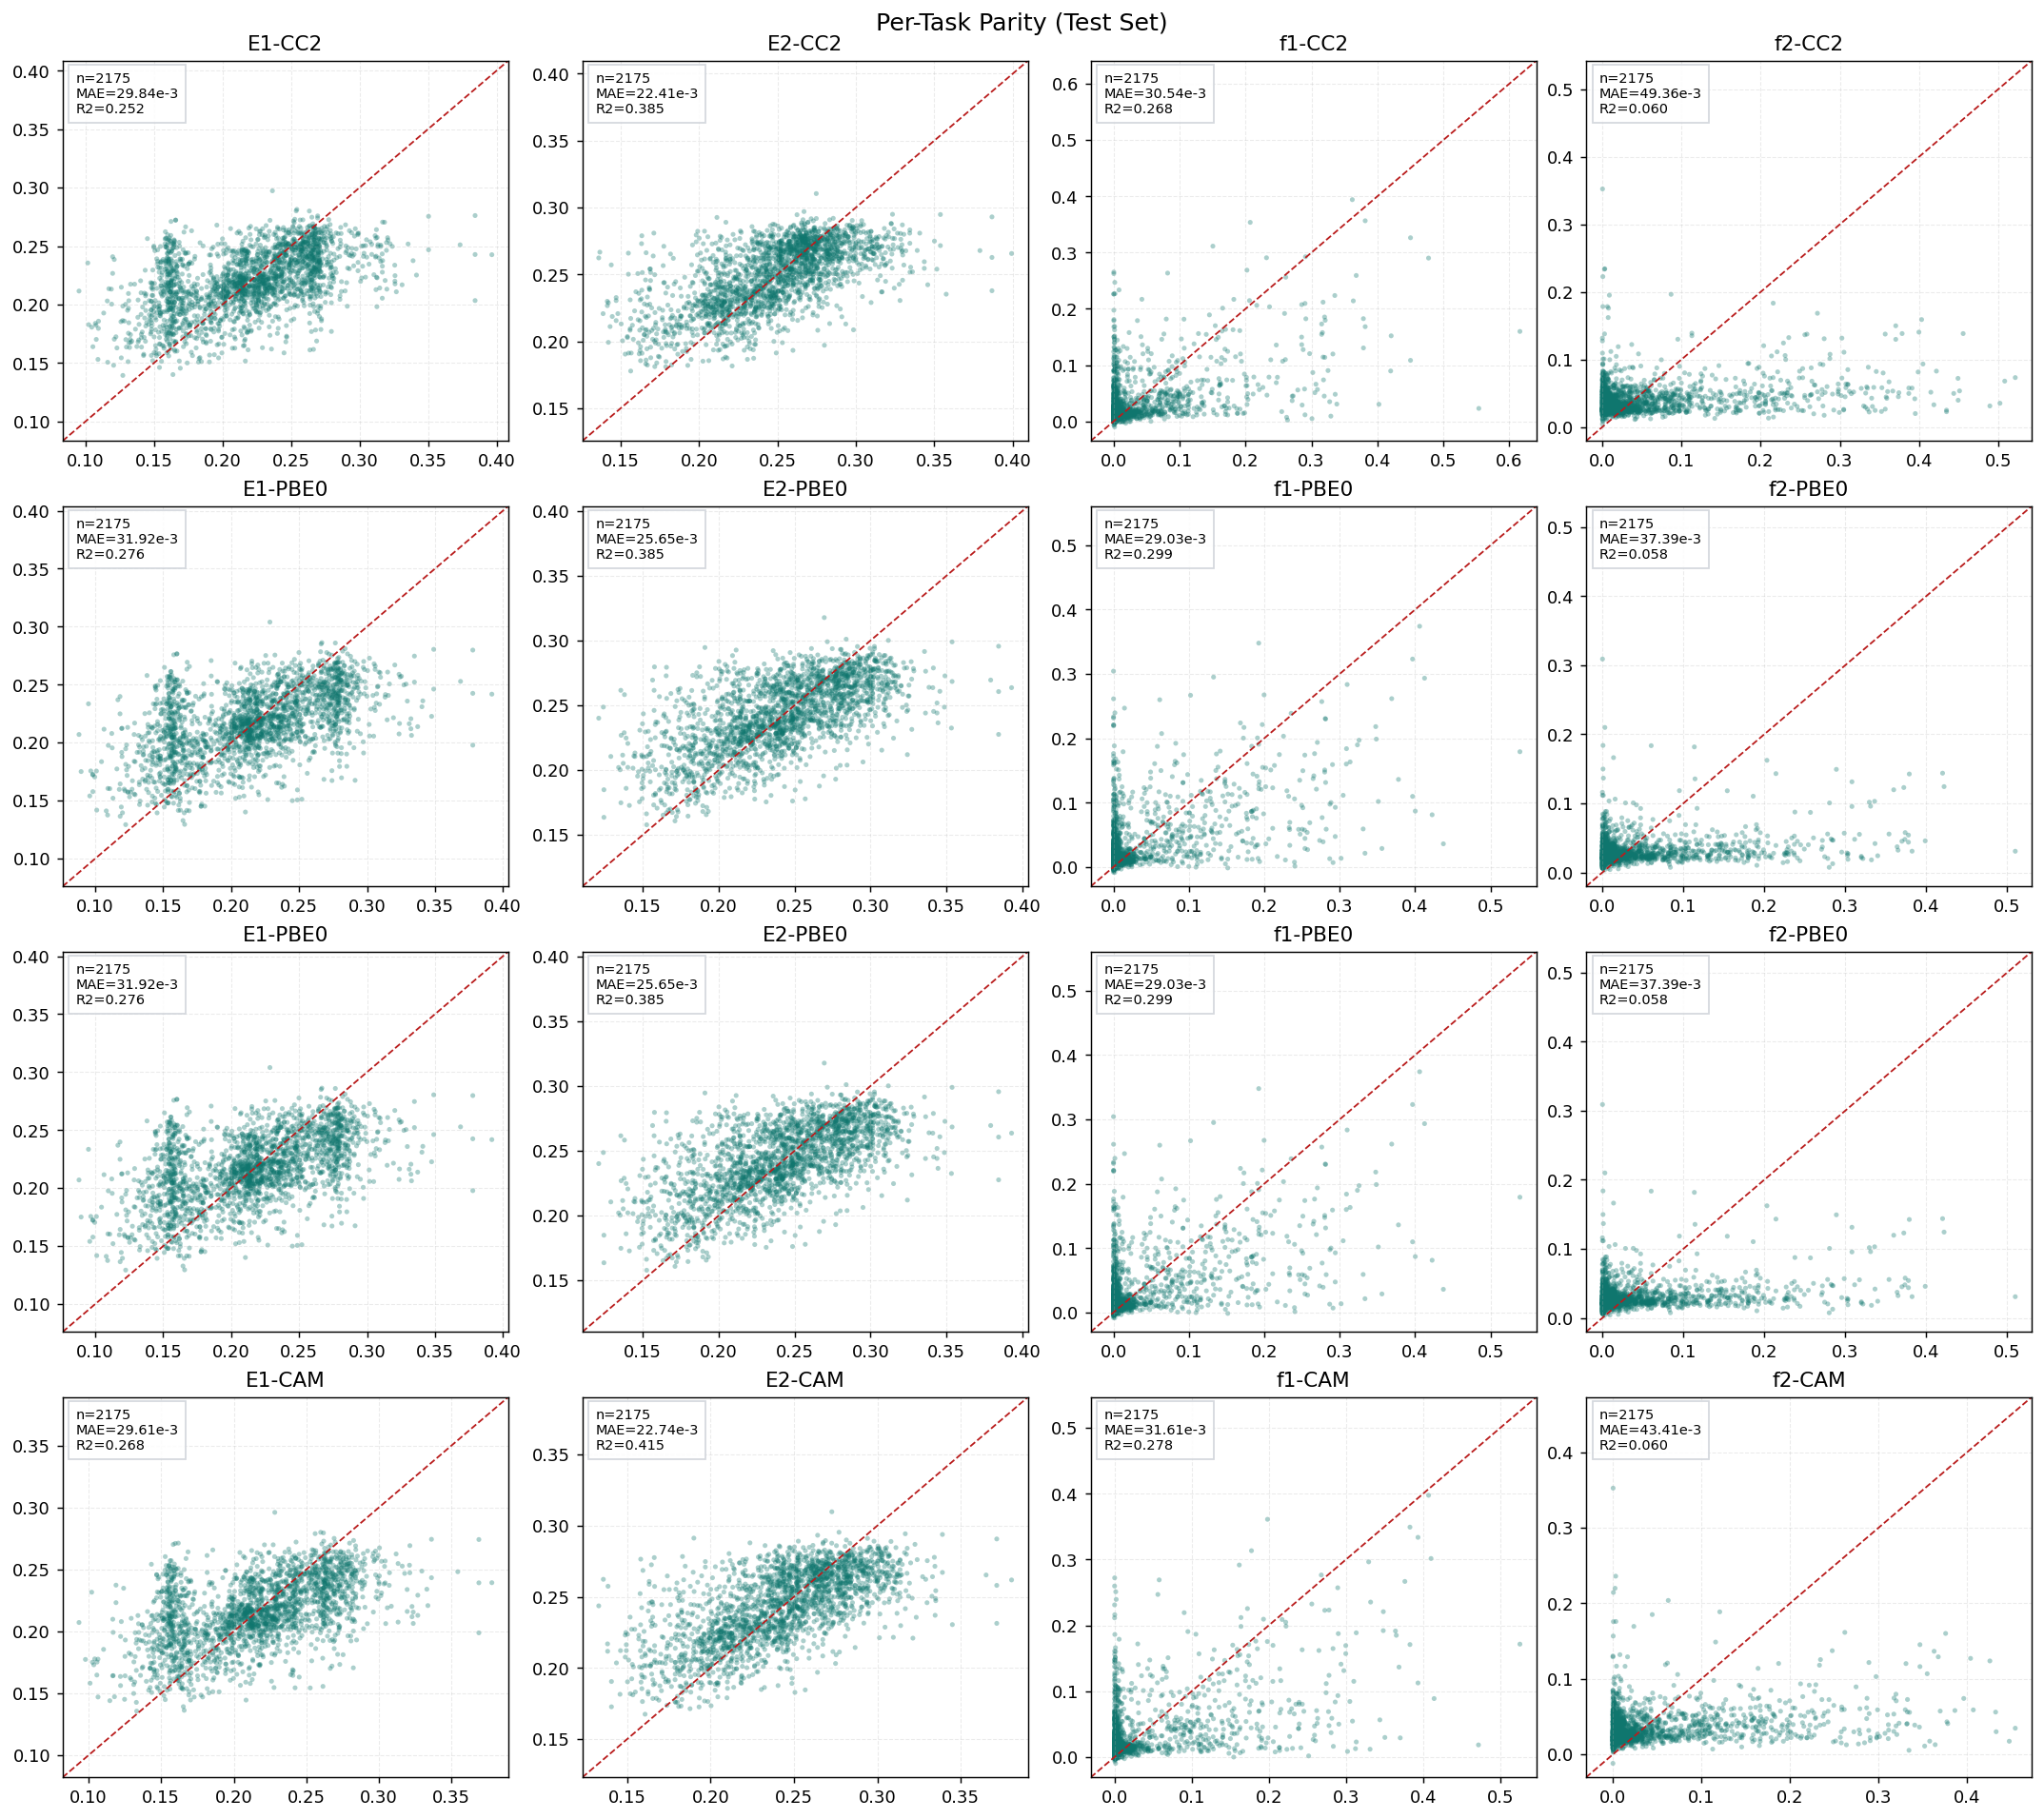

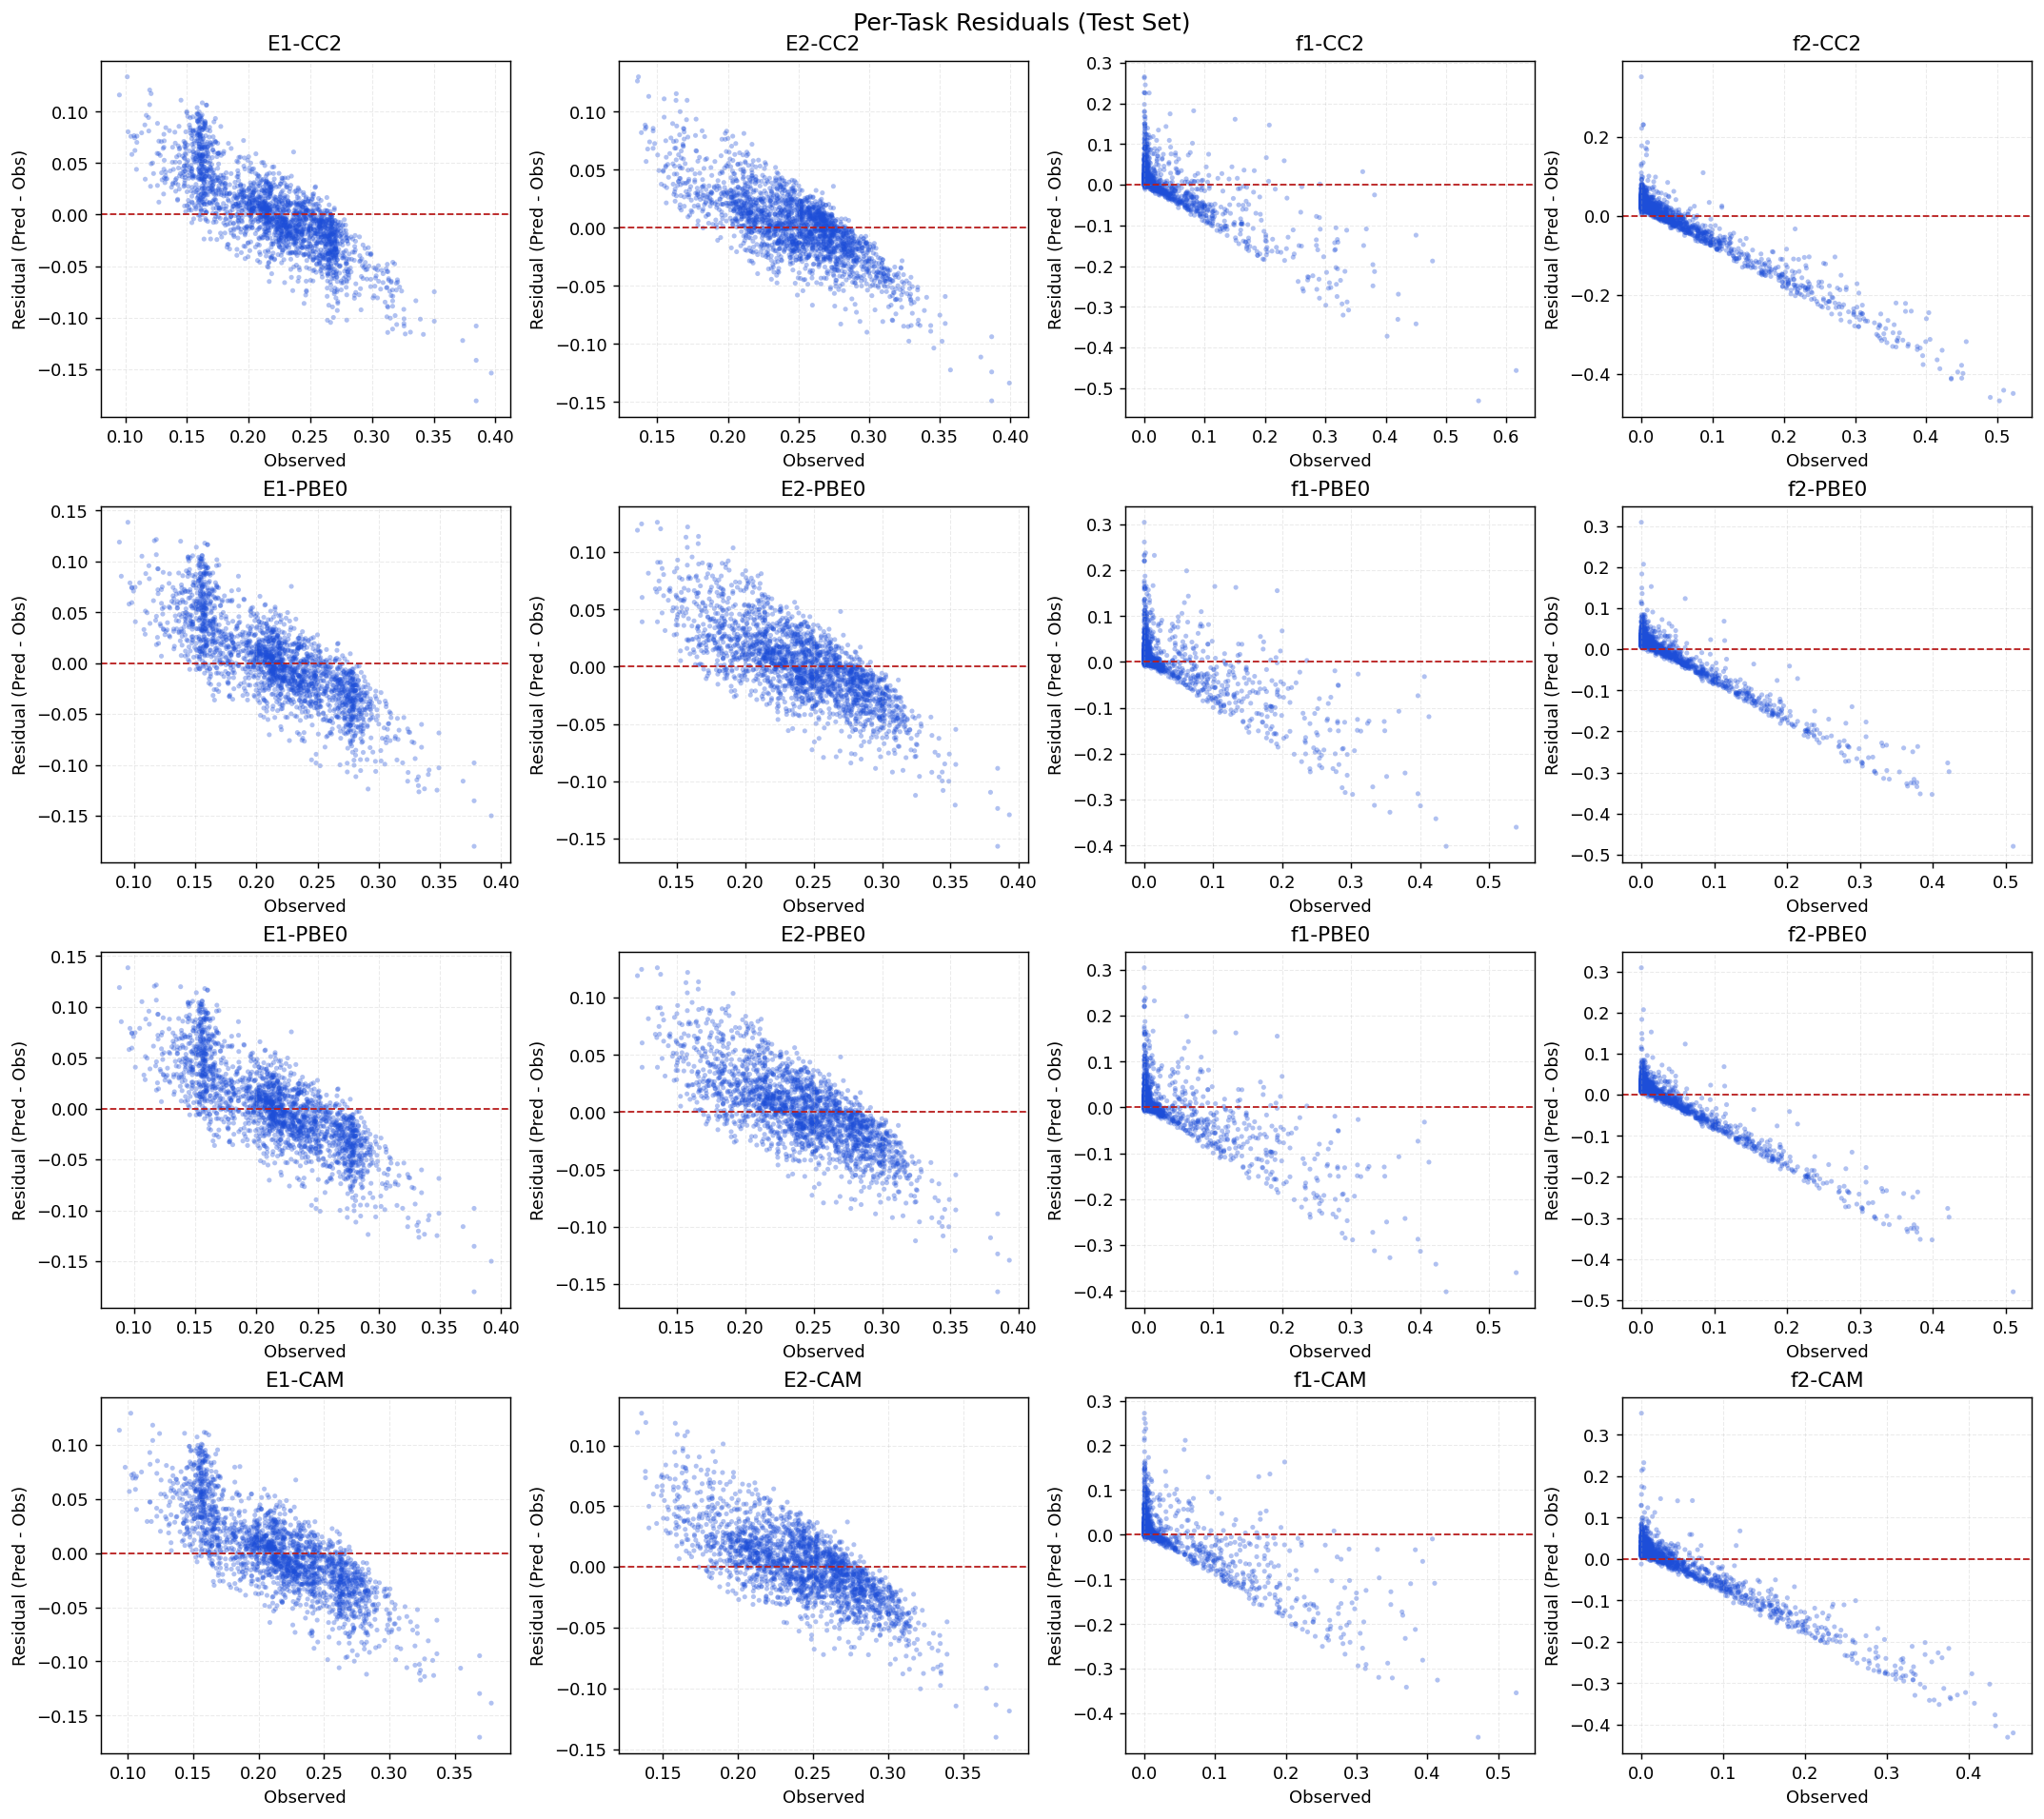

Top tasks by MAE (worst first):


,task,n_obs,mae,rmse,pearson_r,r2
0,f2-CC2,2175,0.049360,0.081365,0.270260,0.059847
1,f2-CAM,2175,0.043413,0.071910,0.265889,0.060238
2,f2-PBE0,2175,0.037395,0.063719,0.258788,0.057643
3,f2-PBE0,2175,0.037395,0.063719,0.258788,0.057643
4,E1-PBE0,2175,0.031919,0.041394,0.530646,0.276190
5,E1-PBE0,2175,0.031919,0.041394,0.530646,0.276190
6,f1-CAM,2175,0.031613,0.057858,0.538372,0.278421
7,f1-CC2,2175,0.030543,0.056887,0.527836,0.267972


In [10]:
# === Diagnostics 1: Per-Task Parity + Residuals (Test Set) ===
required_vars = ['QM8_TASKS', 'test_y_orig', 'test_preds']
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(
        f"Missing required variables: {missing_vars}. Run training/evaluation cells first."
    )

n_tasks = len(QM8_TASKS)
n_cols = 4
n_rows = int(np.ceil(n_tasks / n_cols))

fig_parity, axes_parity = plt.subplots(
    n_rows, n_cols, figsize=(4.1 * n_cols, 3.6 * n_rows), dpi=130, constrained_layout=True
)
axes_parity = np.asarray(axes_parity).reshape(-1)

fig_resid, axes_resid = plt.subplots(
    n_rows, n_cols, figsize=(4.1 * n_cols, 3.6 * n_rows), dpi=130, constrained_layout=True
)
axes_resid = np.asarray(axes_resid).reshape(-1)

task_diag_rows = []

for i, task in enumerate(QM8_TASKS):
    y_true = np.asarray(test_y_orig[:, i], dtype=np.float32)
    y_pred = np.asarray(test_preds[:, i], dtype=np.float32)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    ax_p = axes_parity[i]
    ax_r = axes_resid[i]

    if int(mask.sum()) < 2:
        ax_p.set_title(f"{task}\ninsufficient data")
        ax_p.axis('off')
        ax_r.set_title(f"{task}\ninsufficient data")
        ax_r.axis('off')
        task_diag_rows.append({
            'task': task,
            'n_obs': int(mask.sum()),
            'mae': np.nan,
            'rmse': np.nan,
            'pearson_r': np.nan,
            'r2': np.nan,
        })
        continue

    yt = y_true[mask]
    yp = y_pred[mask]
    err = yp - yt

    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err * err)))
    pear = float(np.corrcoef(yt, yp)[0, 1]) if (np.std(yt) > 0 and np.std(yp) > 0) else np.nan
    ss_res = float(np.sum((yt - yp) ** 2))
    ss_tot = float(np.sum((yt - np.mean(yt)) ** 2))
    r2 = np.nan if ss_tot <= 0 else 1.0 - (ss_res / ss_tot)

    lo = float(min(np.min(yt), np.min(yp)))
    hi = float(max(np.max(yt), np.max(yp)))
    pad = 0.04 * (hi - lo + 1e-12)

    ax_p.scatter(yt, yp, s=8, alpha=0.35, c='#0f766e', edgecolors='none')
    ax_p.plot([lo - pad, hi + pad], [lo - pad, hi + pad], '--', lw=1.0, c='#b91c1c')
    ax_p.set_xlim(lo - pad, hi + pad)
    ax_p.set_ylim(lo - pad, hi + pad)
    ax_p.set_title(f"{task}")
    ax_p.grid(alpha=0.25, linestyle='--', linewidth=0.6)
    ax_p.text(
        0.03, 0.97,
        f"n={len(yt)}\nMAE={mae*1000:.2f}e-3\nR2={r2:.3f}",
        transform=ax_p.transAxes, va='top', ha='left', fontsize=8,
        bbox=dict(facecolor='white', edgecolor='#d1d5db', alpha=0.9),
    )

    ax_r.scatter(yt, err, s=8, alpha=0.35, c='#1d4ed8', edgecolors='none')
    ax_r.axhline(0.0, linestyle='--', linewidth=1.0, color='#b91c1c')
    ax_r.set_title(f"{task}")
    ax_r.set_xlabel('Observed')
    ax_r.set_ylabel('Residual (Pred - Obs)')
    ax_r.grid(alpha=0.25, linestyle='--', linewidth=0.6)

    task_diag_rows.append({
        'task': task,
        'n_obs': int(len(yt)),
        'mae': mae,
        'rmse': rmse,
        'pearson_r': pear,
        'r2': r2,
    })

for j in range(n_tasks, len(axes_parity)):
    axes_parity[j].axis('off')
    axes_resid[j].axis('off')

fig_parity.suptitle('Per-Task Parity (Test Set)', fontsize=14, y=1.01)
fig_resid.suptitle('Per-Task Residuals (Test Set)', fontsize=14, y=1.01)
plt.show()

task_diag_df = pd.DataFrame(task_diag_rows).sort_values('mae', ascending=False).reset_index(drop=True)
print('Top tasks by MAE (worst first):')
display(task_diag_df.head(8))

Low-value stress test for f-tasks (ratio > 1 means low-value region is harder):


,task,n_obs,q20,mae_low20,mae_high80,ratio_low_over_high,bias_low20,bias_high80
0,f2-CC2,2175,0.001568,0.037856,0.052236,0.724715,0.037856,-0.021512
1,f2-PBE0,2175,0.001447,0.027915,0.039765,0.702019,0.027915,-0.014556
2,f2-PBE0,2175,0.001447,0.027915,0.039765,0.702019,0.027915,-0.014556
3,f1-PBE0,2175,0.000248,0.021485,0.030915,0.694960,0.021264,-0.003587
4,f1-PBE0,2175,0.000248,0.021485,0.030915,0.694960,0.021264,-0.003587
5,f2-CAM,2175,0.001200,0.030510,0.046751,0.652606,0.030457,-0.016542
6,f1-CC2,2175,0.000293,0.020804,0.032977,0.630863,0.020775,-0.005908
7,f1-CAM,2175,0.000200,0.019282,0.035217,0.547529,0.019225,-0.005639


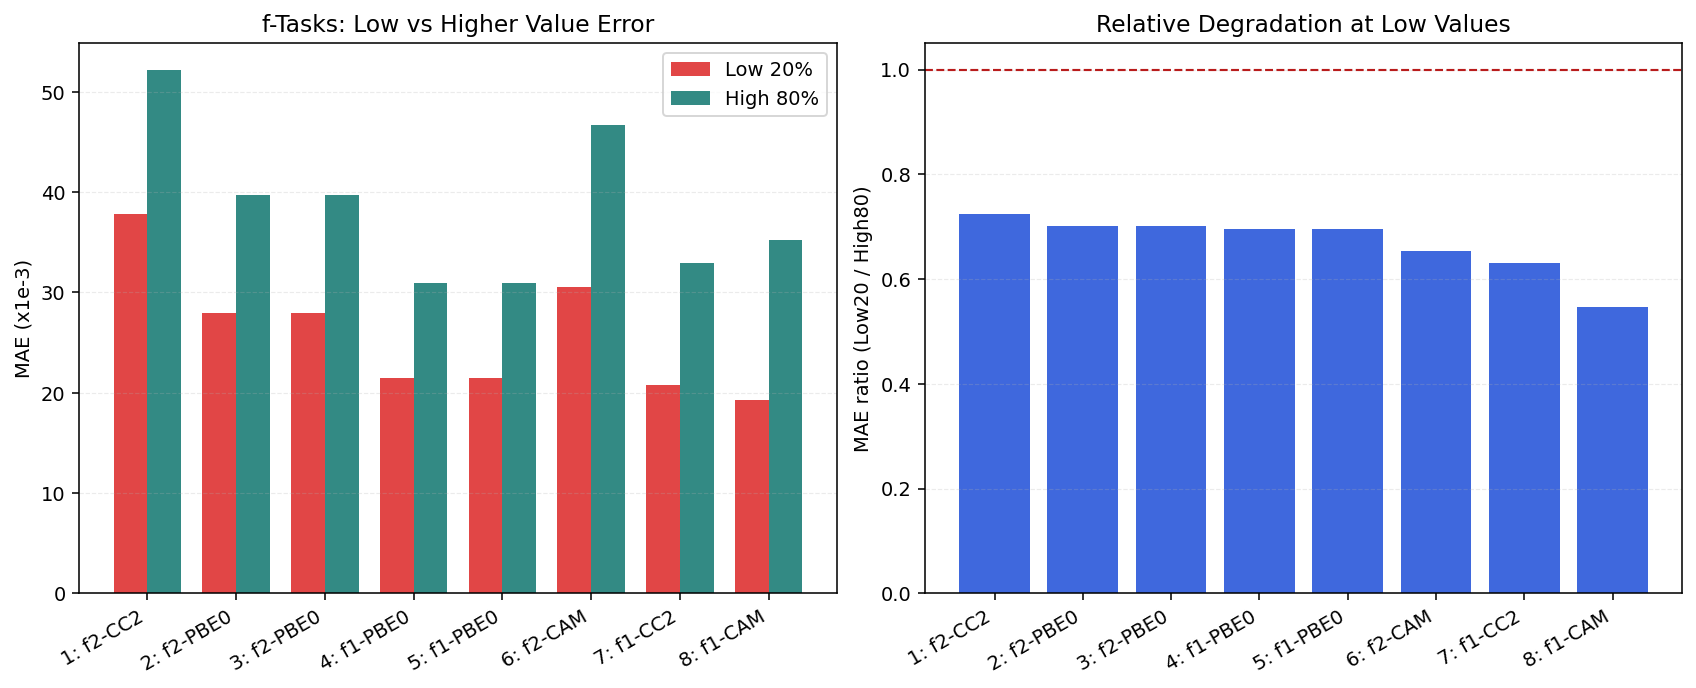

Worst low-value degradation: f2-CC2 | ratio=0.72 | low20 MAE=37.86e-3 | high80 MAE=52.24e-3


In [11]:
# === Diagnostics 2: Low-Value Error Slice for Oscillator Strength Tasks ===
required_vars = ['QM8_TASKS', 'test_y_orig', 'test_preds']
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(
        f"Missing required variables: {missing_vars}. Run training/evaluation cells first."
    )

task_names = [str(t) for t in QM8_TASKS]
f_task_indices = [i for i, name in enumerate(task_names) if name.strip().lower().startswith('f')]

if len(f_task_indices) == 0:
    print('No oscillator-strength tasks detected by name prefix "f".')
else:
    rows = []
    for i in f_task_indices:
        name = task_names[i]
        yt_all = np.asarray(test_y_orig[:, i], dtype=np.float32)
        yp_all = np.asarray(test_preds[:, i], dtype=np.float32)
        mask = np.isfinite(yt_all) & np.isfinite(yp_all)
        yt = yt_all[mask]
        yp = yp_all[mask]

        if yt.size < 8:
            rows.append({
                'task': name,
                'n_obs': int(yt.size),
                'q20': np.nan,
                'mae_low20': np.nan,
                'mae_high80': np.nan,
                'ratio_low_over_high': np.nan,
                'bias_low20': np.nan,
                'bias_high80': np.nan,
            })
            continue

        err = yp - yt
        q20 = float(np.quantile(yt, 0.20))
        low_mask = yt <= q20
        high_mask = yt > q20

        mae_low = float(np.mean(np.abs(err[low_mask]))) if int(low_mask.sum()) > 0 else np.nan
        mae_high = float(np.mean(np.abs(err[high_mask]))) if int(high_mask.sum()) > 0 else np.nan
        bias_low = float(np.mean(err[low_mask])) if int(low_mask.sum()) > 0 else np.nan
        bias_high = float(np.mean(err[high_mask])) if int(high_mask.sum()) > 0 else np.nan
        ratio = (mae_low / mae_high) if (np.isfinite(mae_low) and np.isfinite(mae_high) and mae_high > 0) else np.nan

        rows.append({
            'task': name,
            'n_obs': int(yt.size),
            'q20': q20,
            'mae_low20': mae_low,
            'mae_high80': mae_high,
            'ratio_low_over_high': ratio,
            'bias_low20': bias_low,
            'bias_high80': bias_high,
        })

    low_slice_df = pd.DataFrame(rows).sort_values('ratio_low_over_high', ascending=False).reset_index(drop=True)
    print('Low-value stress test for f-tasks (ratio > 1 means low-value region is harder):')
    display(low_slice_df)

    plot_df = low_slice_df.copy()
    plot_df['task_short'] = [f"{i+1}: {t}" for i, t in enumerate(plot_df['task'].tolist())]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), dpi=140, constrained_layout=True)

    x = np.arange(len(plot_df))
    w = 0.38
    axes[0].bar(x - w/2, plot_df['mae_low20'] * 1000.0, width=w, label='Low 20%', color='#dc2626', alpha=0.85)
    axes[0].bar(x + w/2, plot_df['mae_high80'] * 1000.0, width=w, label='High 80%', color='#0f766e', alpha=0.85)
    axes[0].set_xticks(x, labels=plot_df['task_short'], rotation=30, ha='right')
    axes[0].set_ylabel('MAE (x1e-3)')
    axes[0].set_title('f-Tasks: Low vs Higher Value Error')
    axes[0].grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.6)
    axes[0].legend()

    axes[1].bar(x, plot_df['ratio_low_over_high'], color='#1d4ed8', alpha=0.85)
    axes[1].axhline(1.0, linestyle='--', linewidth=1.1, color='#b91c1c')
    axes[1].set_xticks(x, labels=plot_df['task_short'], rotation=30, ha='right')
    axes[1].set_ylabel('MAE ratio (Low20 / High80)')
    axes[1].set_title('Relative Degradation at Low Values')
    axes[1].grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.6)

    plt.show()

    if np.isfinite(plot_df['ratio_low_over_high']).any():
        worst_idx = int(np.nanargmax(plot_df['ratio_low_over_high'].to_numpy(dtype=np.float32)))
        worst_row = plot_df.iloc[worst_idx]
        print(
            f"Worst low-value degradation: {worst_row['task']} | "
            f"ratio={worst_row['ratio_low_over_high']:.2f} | "
            f"low20 MAE={worst_row['mae_low20'] * 1000:.2f}e-3 | "
            f"high80 MAE={worst_row['mae_high80'] * 1000:.2f}e-3"
        )

=== Affine Calibration Summary (fit on valid, evaluated on test) ===
Macro MAE before: 0.031721
Macro MAE after : 0.032867
Delta (after-before): +0.001147

Tasks with largest test MAE improvement (most negative delta first):


,task,a_slope,b_intercept,test_mae_before,test_mae_after,test_delta
0,E2-CC2,0.931759,0.015629,0.022410,0.022427,0.000017
1,E2-CAM,0.918018,0.019036,0.022742,0.022853,0.000111
2,E2-PBE0,0.899330,0.023371,0.025655,0.025897,0.000242
3,E2-PBE0,0.899330,0.023371,0.025655,0.025897,0.000242
4,E1-CAM,0.841979,0.032847,0.029615,0.029960,0.000345
5,E1-PBE0,0.850220,0.030950,0.031919,0.032276,0.000357
6,E1-PBE0,0.850220,0.030950,0.031919,0.032276,0.000357
7,E1-CC2,0.841207,0.033663,0.029842,0.030218,0.000376


Tasks with largest test MAE degradation (if any):


,task,a_slope,b_intercept,test_mae_before,test_mae_after,test_delta
11,f1-CAM,0.789736,0.005495,0.031613,0.032755,0.001142
12,f2-PBE0,1.042335,0.005883,0.037395,0.040723,0.003328
13,f2-PBE0,1.042336,0.005883,0.037395,0.040723,0.003328
14,f2-CC2,1.154577,0.002760,0.049360,0.052697,0.003336
15,f2-CAM,0.966441,0.008269,0.043413,0.046770,0.003357


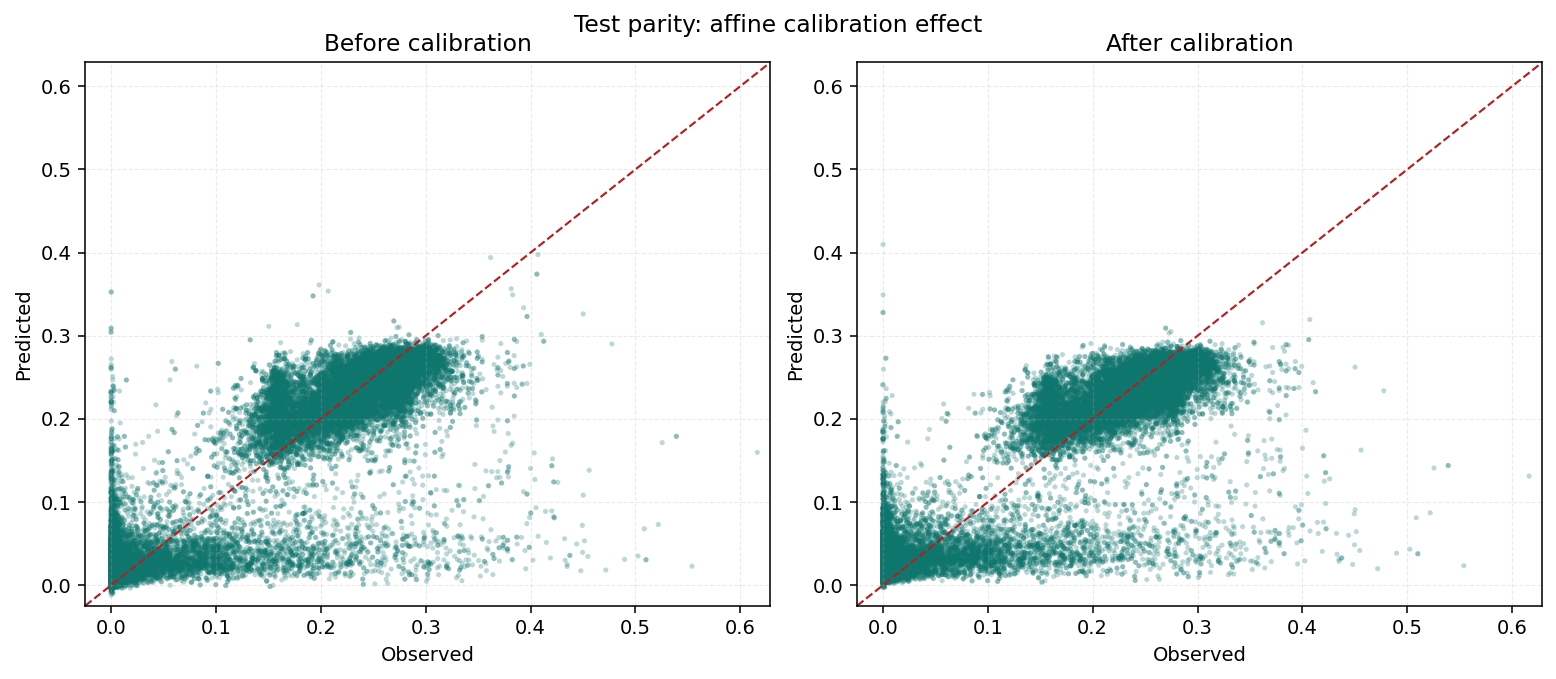

Duplicate task-name diagnostics:


,task_name,idx_a,idx_b,same_true_values,same_pred_values,corr_true,corr_pred
0,E1-PBE0,4,8,True,False,1.0,1.0
1,E2-PBE0,5,9,True,False,1.0,1.0
2,f1-PBE0,6,10,True,False,1.0,1.0
3,f2-PBE0,7,11,True,False,1.0,1.0


In [12]:
# === Diagnostics 3: Post-hoc Affine Calibration (fit on valid, apply to test) ===
required_vars = ['QM8_TASKS', 'valid_y_orig', 'test_y_orig', 'valid_preds', 'test_preds']
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(
        f"Missing required variables: {missing_vars}. Run evaluation cell first."
    )

task_names = [str(t) for t in QM8_TASKS]
valid_true = np.asarray(valid_y_orig, dtype=np.float32)
test_true = np.asarray(test_y_orig, dtype=np.float32)
valid_pred = np.asarray(valid_preds, dtype=np.float32)
test_pred = np.asarray(test_preds, dtype=np.float32)

if valid_true.shape != valid_pred.shape or test_true.shape != test_pred.shape:
    raise RuntimeError(
        f"Shape mismatch: valid_true={valid_true.shape}, valid_pred={valid_pred.shape}, "
        f"test_true={test_true.shape}, test_pred={test_pred.shape}"
    )

def _safe_affine_fit(x_pred, y_true):
    # Fit y_true ~= a * x_pred + b on finite entries
    m = np.isfinite(x_pred) & np.isfinite(y_true)
    x = x_pred[m]
    y = y_true[m]
    if x.size < 3:
        return 1.0, 0.0, int(x.size), 'too_few_points'
    if float(np.std(x)) < 1e-12:
        return 1.0, float(np.mean(y) - np.mean(x)), int(x.size), 'near_constant_pred'
    a, b = np.polyfit(x, y, deg=1)
    return float(a), float(b), int(x.size), 'ok'

def _task_mae(y_t, y_p):
    m = np.isfinite(y_t) & np.isfinite(y_p)
    return float(np.mean(np.abs(y_t[m] - y_p[m]))) if int(m.sum()) > 0 else np.nan

def _macro_mae(y_t2d, y_p2d):
    maes = [_task_mae(y_t2d[:, i], y_p2d[:, i]) for i in range(y_t2d.shape[1])]
    return float(np.nanmean(maes)), np.asarray(maes, dtype=np.float32)

calib_params = []
test_pred_cal = test_pred.copy()
valid_pred_cal = valid_pred.copy()

for i, name in enumerate(task_names):
    a, b, n_fit, status = _safe_affine_fit(valid_pred[:, i], valid_true[:, i])
    valid_pred_cal[:, i] = a * valid_pred[:, i] + b
    test_pred_cal[:, i] = a * test_pred[:, i] + b

    mae_valid_before = _task_mae(valid_true[:, i], valid_pred[:, i])
    mae_valid_after = _task_mae(valid_true[:, i], valid_pred_cal[:, i])
    mae_test_before = _task_mae(test_true[:, i], test_pred[:, i])
    mae_test_after = _task_mae(test_true[:, i], test_pred_cal[:, i])

    calib_params.append({
        'task': name,
        'n_fit': n_fit,
        'status': status,
        'a_slope': a,
        'b_intercept': b,
        'valid_mae_before': mae_valid_before,
        'valid_mae_after': mae_valid_after,
        'valid_delta': mae_valid_after - mae_valid_before,
        'test_mae_before': mae_test_before,
        'test_mae_after': mae_test_after,
        'test_delta': mae_test_after - mae_test_before,
    })

calib_df = pd.DataFrame(calib_params)
calib_df = calib_df.sort_values('test_delta', ascending=True).reset_index(drop=True)

macro_before, per_task_before = _macro_mae(test_true, test_pred)
macro_after, per_task_after = _macro_mae(test_true, test_pred_cal)
delta_macro = macro_after - macro_before

print('=== Affine Calibration Summary (fit on valid, evaluated on test) ===')
print(f'Macro MAE before: {macro_before:.6f}')
print(f'Macro MAE after : {macro_after:.6f}')
print(f'Delta (after-before): {delta_macro:+.6f}')
print('')
print('Tasks with largest test MAE improvement (most negative delta first):')
display(calib_df[['task', 'a_slope', 'b_intercept', 'test_mae_before', 'test_mae_after', 'test_delta']].head(8))

print('Tasks with largest test MAE degradation (if any):')
display(calib_df[['task', 'a_slope', 'b_intercept', 'test_mae_before', 'test_mae_after', 'test_delta']].tail(5))

# Quick aggregated parity comparison (test, all tasks flattened).
def _flatten_finite(y_t2d, y_p2d):
    yt = np.asarray(y_t2d, dtype=np.float32).reshape(-1)
    yp = np.asarray(y_p2d, dtype=np.float32).reshape(-1)
    m = np.isfinite(yt) & np.isfinite(yp)
    return yt[m], yp[m]

yt_b, yp_b = _flatten_finite(test_true, test_pred)
yt_a, yp_a = _flatten_finite(test_true, test_pred_cal)

lo = float(np.min(np.concatenate([yt_b, yp_b, yp_a])))
hi = float(np.max(np.concatenate([yt_b, yp_b, yp_a])))
pad = 0.02 * (hi - lo + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), dpi=140, constrained_layout=True)
for ax, yp, title in [
    (axes[0], yp_b, 'Before calibration'),
    (axes[1], yp_a, 'After calibration'),
]:
    ax.scatter(yt_b, yp, s=7, alpha=0.28, c='#0f766e', edgecolors='none')
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], '--', lw=1.1, c='#b91c1c')
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel('Observed')
    ax.set_ylabel('Predicted')
    ax.set_title(title)
    ax.grid(alpha=0.25, linestyle='--', linewidth=0.6)

fig.suptitle('Test parity: affine calibration effect', fontsize=12, y=1.02)
plt.show()

# Duplicate task-name diagnostics (name duplicates and column identity check).
from collections import defaultdict
name_to_idx = defaultdict(list)
for i, n in enumerate(task_names):
    name_to_idx[n].append(i)

dup_rows = []
for name, idxs in name_to_idx.items():
    if len(idxs) < 2:
        continue
    base = idxs[0]
    for j in idxs[1:]:
        yt0 = test_true[:, base]
        yt1 = test_true[:, j]
        yp0 = test_pred[:, base]
        yp1 = test_pred[:, j]
        mt = np.isfinite(yt0) & np.isfinite(yt1)
        mp = np.isfinite(yp0) & np.isfinite(yp1)
        same_true = bool(np.allclose(yt0[mt], yt1[mt], rtol=1e-7, atol=1e-9)) if int(mt.sum()) > 0 else False
        same_pred = bool(np.allclose(yp0[mp], yp1[mp], rtol=1e-7, atol=1e-9)) if int(mp.sum()) > 0 else False
        corr_true = float(np.corrcoef(yt0[mt], yt1[mt])[0, 1]) if int(mt.sum()) > 2 else np.nan
        corr_pred = float(np.corrcoef(yp0[mp], yp1[mp])[0, 1]) if int(mp.sum()) > 2 else np.nan
        dup_rows.append({
            'task_name': name,
            'idx_a': int(base),
            'idx_b': int(j),
            'same_true_values': same_true,
            'same_pred_values': same_pred,
            'corr_true': corr_true,
            'corr_pred': corr_pred,
        })

dup_diag_df = pd.DataFrame(dup_rows)
if len(dup_diag_df) == 0:
    print('No duplicate task names detected.')
else:
    print('Duplicate task-name diagnostics:')
    display(dup_diag_df)